# Getting Started

## First STLDriver object

In [1]:
import stlrom as stl
d = stl.STLDriver()
d.parse_string('signal x,y')
print(d)

# STLDriver object defined as
signal x, y

# With formulas

# Data:
No data yet.


## Adding signal data

In [2]:
d.add_sample([0, 0.1, 0.2])
d.add_sample([0.5, -0.1, -0.2])
d.add_sample([1, 0, 0])
print(d)

# STLDriver object defined as
signal x, y

# With formulas

# Data:

# Signal x:
3 samples from t0=0 to t_end=1

# Signal y:
3 samples from t0=0 to t_end=1



## First Plots

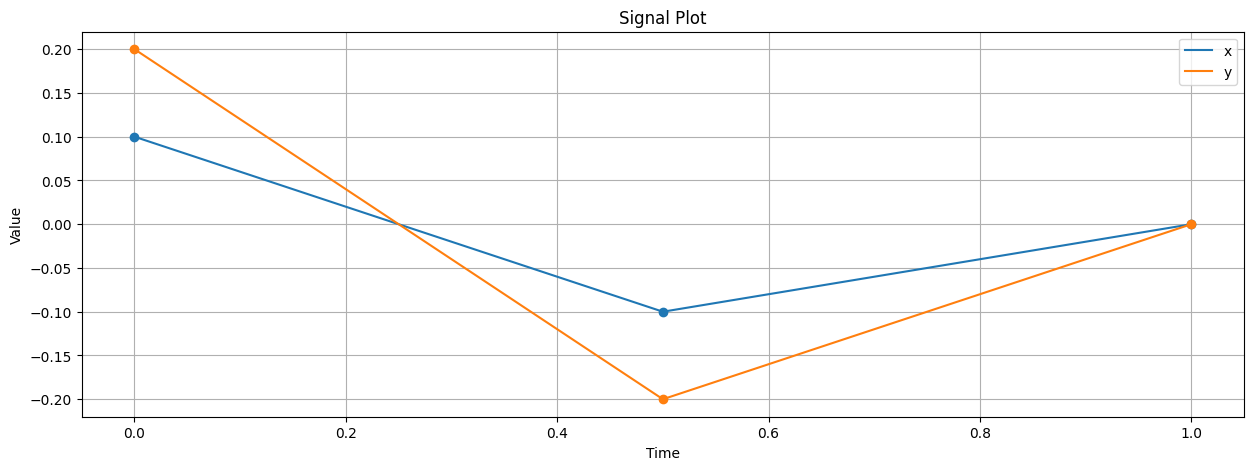

In [3]:
import matplotlib.pyplot as plt

ax = d.plot_signal('x')  # plots signal x, returns axis
ax = d.plot_signal('y',ax=ax) # plots signal y on the same axis

## First Predicates

In [4]:
d.parse_string("""
mu_x    := x[t]>0
mu_y    := y[t]>0
mu_comp := x[t]<y[t]
""")
print(d)

# STLDriver object defined as
signal x, y

# With formulas
mu_comp:= x[t] < y[t]
mu_x:= x[t] > 0
mu_y:= y[t] > 0

# Data:

# Signal x:
3 samples from t0=0 to t_end=1

# Signal y:
3 samples from t0=0 to t_end=1



## Robustness Evaluation

In [5]:
d.set_semantics('BOOLEAN')
r_mu = d.eval_rob('mu_x',0,1)
print(r_mu)

begin_time: 0  end_time: 1
time:          0  value:          1  derivative:          0
time:       0.25  value:          0  derivative:          0



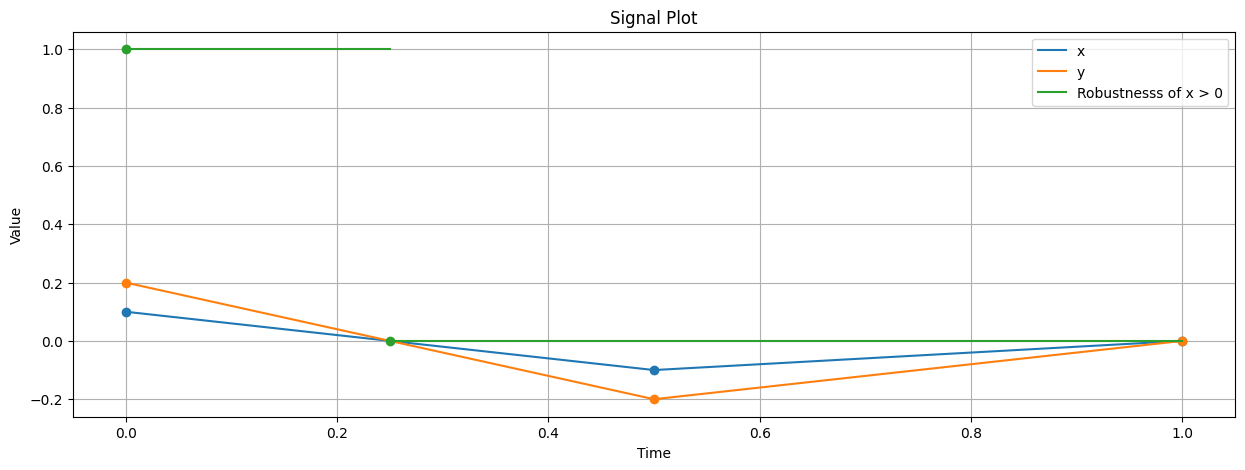

In [6]:
ax = d.plot_signal('x')  # plots signal x, returns axis
ax = d.plot_signal('y',ax=ax) # plots signal y on the same axis
ax = r_mu.plot(label='Robustnesss of x > 0', ax=ax)


# Signal Generation

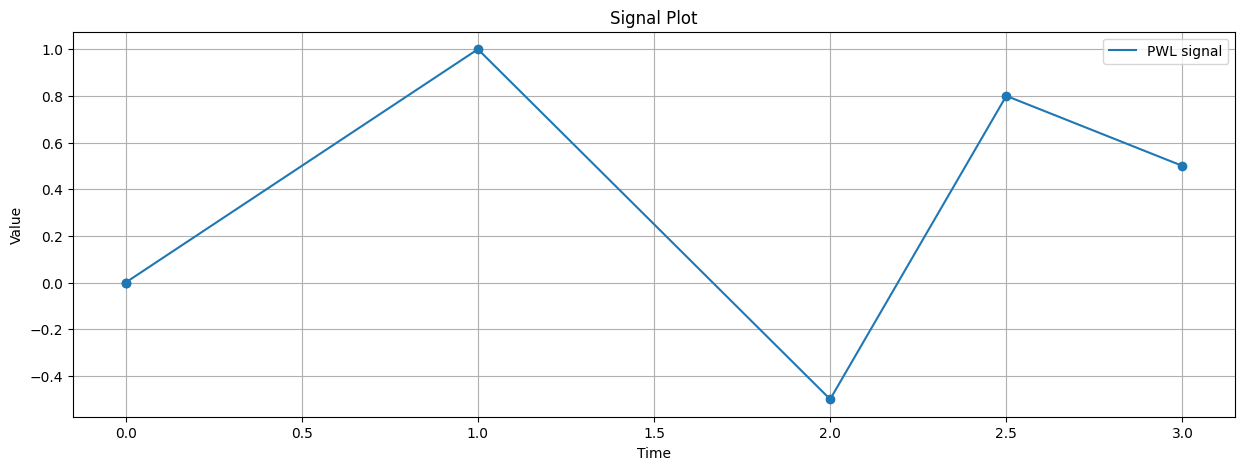

In [7]:
from stlrom import PWLSignalGen

pwl_gen = PWLSignalGen(times=[0, 1., 2., 2.5, 3.],
                       values=[0., 1., -0.5, 0.8, 0.5])
pwl_signal = pwl_gen.get_signal(t0=0, tf=3)
pwl_signal.plot(label='PWL signal');

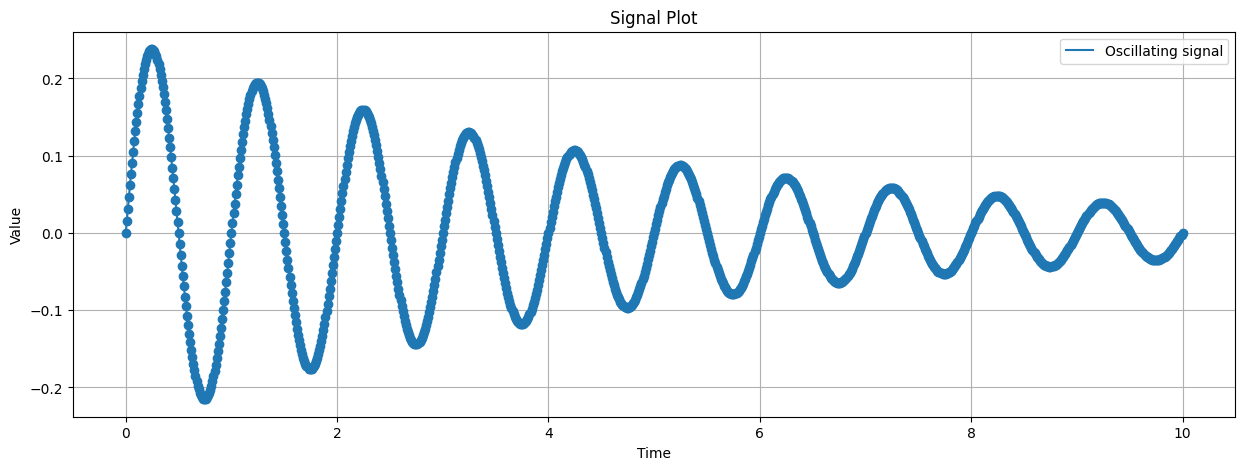

In [8]:
from stlrom import OscillSignalGen

osc_gen = OscillSignalGen(period=1, amplitude=0.25, base=0, damp=-0.2)
osc_signal = osc_gen.get_signal(t0=0, tf=10, dt=0.01)
osc_signal.plot(label='Oscillating signal');


# Robustness of Equality

In [9]:
d2 = stl.STLDriver()
d2.parse_string("""
    signal x
    mu_eq := x[t] == 0
    """)

d2.set_signals([osc_signal])
print(d2)

# STLDriver object defined as
signal x

# With formulas
mu_eq:= x[t] == 0

# Data:

# Signal x:
1001 samples from t0=0 to t_end=10



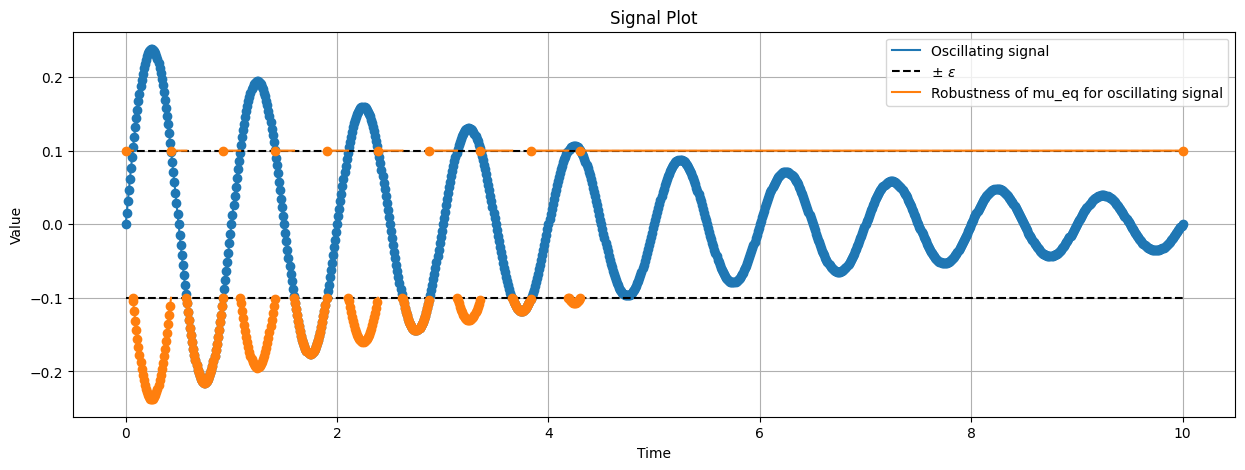

In [10]:
stl.Signal.set_Eps(0.1)

rob_eq = d2.eval_rob('mu_eq', 0, 10)

ax = osc_signal.plot(label='Oscillating signal');
ax.plot([0, osc_signal.end_time], [stl.Signal.get_Eps(), stl.Signal.get_Eps()], linestyle='--', color='black', label="± $\\varepsilon$")
ax.plot([0, osc_signal.end_time], [-stl.Signal.get_Eps(), -stl.Signal.get_Eps()], linestyle='--', color='black')
ax = rob_eq.plot(label='Robustness of mu_eq for oscillating signal', ax=ax);



In [11]:
stl.Signal.set_Eps(1e-12)

# Temperature Example

## Generating Signal

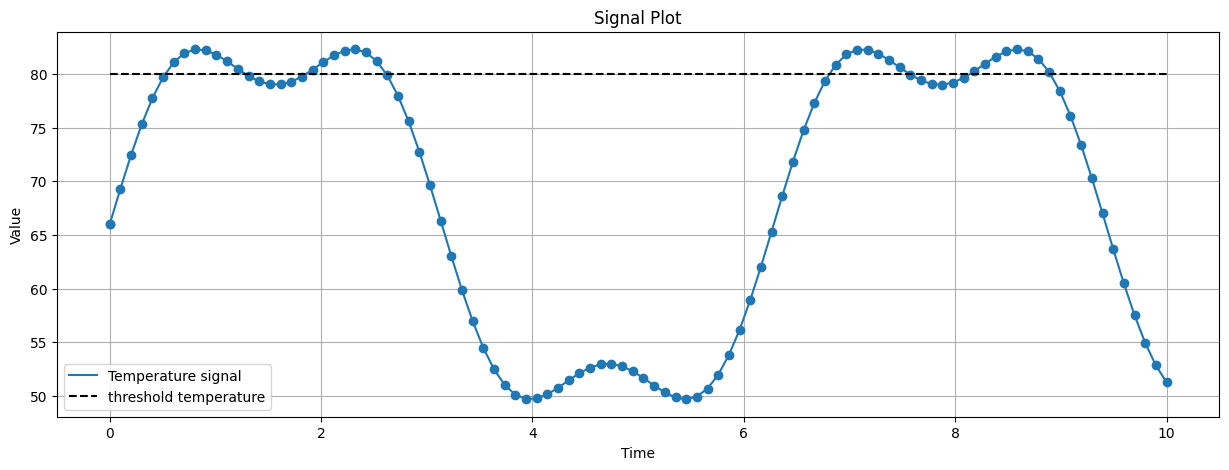

In [12]:
import numpy as np
times = np.linspace(0, 10, 100)
values = 66 + 18 * np.sin(times) + 5 * np.sin(3 * times)

temp_signal = PWLSignalGen(times = times, values = values).get_signal()

ax = temp_signal.plot(label='Temperature signal');
ax.plot([0, temp_signal.end_time], [80, 80], linestyle='--', color='black', label="threshold temperature");
ax.legend();


## Parsing Formulas

In [13]:
d3 = stl.STLDriver()

d3.parse_string("""
    signal temp
                
    # Setting parameters
    param Tmax = 80
                
    # Temperature should always be below Tmax
    phi_always := alw[0, 3] (temp[t] < Tmax)
    
    # If temperature is above Tmax, it should eventually be below Tmax within 2 seconds
    phi := alw[0, 3] ((temp[t] >= Tmax) => ev[0, 2] (temp[t] < Tmax))
    """)

d3.set_signals([temp_signal])

## Robustness of First Formula

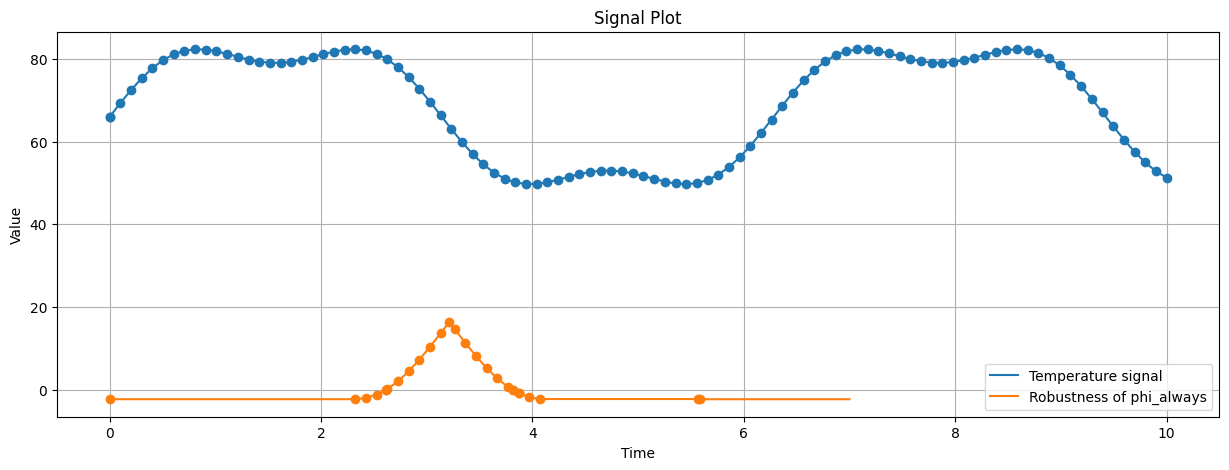

In [14]:
stl.Signal.set_BigM(100)

r, r_low, r_up = d3.eval_online_rob('phi_always', 0, 7)


ax = temp_signal.plot(label='Temperature signal');
r.plot(label='Robustness of phi_always', ax=ax);
# r_low.plot(label='Lower bound of robustness of phi_always', ax=ax);
# r_up.plot(label='Upper bound of robustness of phi_always', ax=ax);

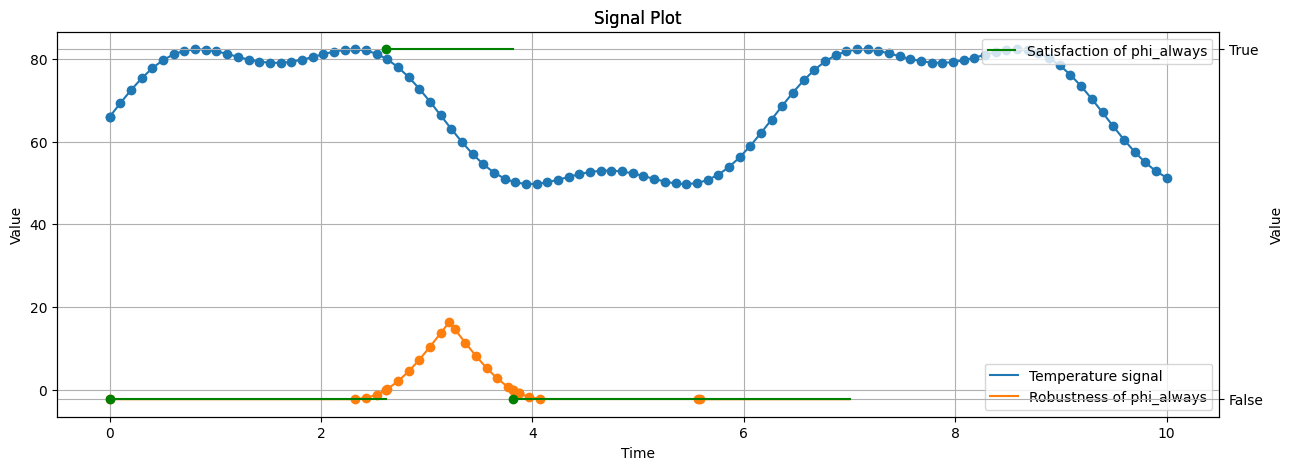

In [15]:
d3.set_semantics('BOOLEAN')

r_boolean = d3.eval_rob('phi_always', 0, 7)

ax = temp_signal.plot(label='Temperature signal');
r.plot(label='Robustness of phi_always', ax=ax);

ax_bool = ax.twinx(); ax_bool.set_yticks([0, 1]); ax_bool.set_yticklabels(['False', 'True']);
r_boolean.plot(label ='Satisfaction of phi_always', ax=ax_bool, color='green');

## Robustness Map and Online Monitoring

In [16]:
d3.set_semantics('SPACE')
r_phi, _, _ = d3.eval_online_rob('phi', 0, 7)
rob_map = d3.get_online_robustness_map('phi')

stl.plot_rob_map_widget(rob_map)

interactive(children=(Dropdown(description='Robustness:', options=(('Robustness', 'z'), ('Lower', 'z_low'), ('…